# SIM (UNIT) → FastPM Haloscope enrichment (tidal inputs)

Variant of `SIM_to_FASTPM_unitsim_fastpm_mn5.ipynb` that conditions Haloscope on:

- **`t_over_u`**: Rockstar column `T/|U|` (kinetic-to-potential ratio) from the `.list` / hlist catalogs.
- **`tidal_anisotropy`**: precomputed tidal descriptor from `output/*/tidal_anisotropy/` (density-field pipeline).

**Quick run:** set `QUICK_RUN = True` in the config cell (caps halos and reads one descriptor batch per simulation).

**Full run on Taurus:**

```bash
sbatch slurm/sim_to_fastpm/main_sim_to_fastpm_haloscope_tidal.slurm
```

Equivalent local/Slurm entry point: `scripts/run_sim_to_fastpm_haloscope_tidal.py`.

## 0. Python path

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src" / "density_field_properties").is_dir():
    REPO_ROOT = Path.cwd().parent

sys.path.insert(0, str(REPO_ROOT / "src"))

## 1. Configuration

| Quantity | Value |
|----------|--------|
| UNIT SIM | `/data5/UNITSIM/fixedAmp_InvPhase_001/ROCKSTAR/outputs` → `hlists/hlist_1.00000.list.bz2` |
| FastPM | `/data21/users/mruiz/fastpm_MN5/fastpm_tfm/rockstar_out_pm/out_8.list` |
| UNIT descriptors | `output/unit_files/tidal_anisotropy/` |
| FastPM descriptors | `output/fast_pm_bigfile/tidal_anisotropy/` |
| Input features | `t_over_u`, `tidal_anisotropy` |

Set `QUICK_RUN = True` for smoke limits (`SMOKE_*` in `config.py`).

In [3]:
from density_field_properties.haloscope.sim_to_fastpm import config
from density_field_properties.haloscope.sim_to_fastpm.config import (
    ENRICHED_TIDAL_PARQUET_NAME,
    OUTPUT_DIR_TIDAL,
    TIDAL_DENSITY_N_GRID,
    TIDAL_INPUT_FEATURES,
    default_fastpm_list_path,
    default_fastpm_tidal_descriptors_dir,
    default_sim_hlist_path,
    default_unit_tidal_descriptors_dir,
    max_descriptor_batch_files_for_run,
    max_fastpm_halos_for_run,
    max_sim_halos_for_run,
    min_bin_size_for_run,
)

config.QUICK_RUN = True
CALIBRATE_MASS = False

MAX_SIM_HALOS = max_sim_halos_for_run(config.QUICK_RUN)
MAX_FASTPM_HALOS = max_fastpm_halos_for_run(config.QUICK_RUN)
MAX_DESCRIPTOR_BATCHES = max_descriptor_batch_files_for_run(config.QUICK_RUN)
MIN_BIN_SIZE = min_bin_size_for_run(config.QUICK_RUN)

SIM_PATH = default_sim_hlist_path()
FASTPM_PATH = default_fastpm_list_path()
UNIT_DESCRIPTORS_DIR = REPO_ROOT / default_unit_tidal_descriptors_dir()
FASTPM_DESCRIPTORS_DIR = REPO_ROOT / default_fastpm_tidal_descriptors_dir()
OUTPUT_DIR = OUTPUT_DIR_TIDAL
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(
    f"QUICK_RUN={config.QUICK_RUN}  MAX_SIM={MAX_SIM_HALOS}  "
    f"MAX_FASTPM={MAX_FASTPM_HALOS}  MAX_DESCRIPTOR_BATCHES={MAX_DESCRIPTOR_BATCHES}"
)

QUICK_RUN=True  MAX_SIM=8000  MAX_FASTPM=8000  MAX_DESCRIPTOR_BATCHES=1


## 2. Load catalogs (includes Rockstar `T/|U|` as `t_over_u`)

In [17]:
from density_field_properties.haloscope.sim_to_fastpm.load_catalogs import (
    load_fastpm_target_catalog,
    load_unit_sim_training_catalog,
)

halos_sim = load_unit_sim_training_catalog(SIM_PATH, max_halos=MAX_SIM_HALOS)
halos_fastpm = load_fastpm_target_catalog(FASTPM_PATH, max_halos=MAX_FASTPM_HALOS)
print(f"UNIT hosts: {len(halos_sim)}")
print(f"FastPM halos: {len(halos_fastpm)}")

UNIT hosts: 7162
FastPM halos: 8000


## 3. Attach tidal anisotropy from precomputed descriptor batches

In [18]:
from density_field_properties.haloscope.sim_to_fastpm.config import (
    FASTPM_BOXSIZE_MPC_H,
    SIM_BOXSIZE_MPC_H,
)
from density_field_properties.haloscope.sim_to_fastpm.tidal_features import (
    attach_tidal_anisotropy,
    filter_finite_input_features,
)

halos_sim = attach_tidal_anisotropy(
    halos_sim,
    UNIT_DESCRIPTORS_DIR,
    SIM_BOXSIZE_MPC_H,
    TIDAL_DENSITY_N_GRID,
    max_batch_files=MAX_DESCRIPTOR_BATCHES,
)
halos_fastpm = attach_tidal_anisotropy(
    halos_fastpm,
    FASTPM_DESCRIPTORS_DIR,
    FASTPM_BOXSIZE_MPC_H,
    TIDAL_DENSITY_N_GRID,
    max_batch_files=MAX_DESCRIPTOR_BATCHES,
)

halos_sim = filter_finite_input_features(halos_sim, TIDAL_INPUT_FEATURES)
halos_fastpm = filter_finite_input_features(halos_fastpm, TIDAL_INPUT_FEATURES)
print(f"UNIT with tidal inputs: {len(halos_sim)}")
print(f"FastPM with tidal inputs: {len(halos_fastpm)}")
halos_sim[list(TIDAL_INPUT_FEATURES)].describe()

UNIT with tidal inputs: 7162
FastPM with tidal inputs: 1


,t_over_u,tidal_anisotropy
count,7162.000000,7162.000000
mean,0.571666,7.027268
std,0.064644,516.862643
min,0.456300,-1112.097675
25%,0.534300,0.812174
50%,0.556800,1.354811
75%,0.588000,2.426490
max,1.287100,43521.878944


## 4. Optional mass calibration

In [19]:
from density_field_properties.haloscope.sim_to_fastpm.mass_matching import abundance_match_mass

if CALIBRATE_MASS:
    halos_fastpm["M200b_cal"] = abundance_match_mass(
        halos_fastpm["M200b"].to_numpy(), halos_sim["M200b"].to_numpy()
    )
    MASS_COL_FASTPM = "M200b_cal"
else:
    MASS_COL_FASTPM = "M200b"

## 5. SIM hold-out validation

In [20]:
import numpy as np
from density_field_properties.haloscope.sim_to_fastpm.training import (
    default_mass_bin_edges,
    holdout_validate_sim_bins,
)

BIN_EDGES = default_mass_bin_edges(np.log10(halos_sim["M200b"].max()))
val_results = holdout_validate_sim_bins(
    halos_sim,
    BIN_EDGES,
    min_bin_size=MIN_BIN_SIZE,
    input_features=TIDAL_INPUT_FEATURES,
)

here
acceptance rate is  97.36842105263158 %
here
acceptance rate is  96.69421487603306 %
here
acceptance rate is  96.52173913043478 %


/home/arnes/miniconda3/envs/density_field_properties/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (444). n_quantiles is set to n_samples.
  warnings.warn(
/home/arnes/miniconda3/envs/density_field_properties/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (471). n_quantiles is set to n_samples.
  warnings.warn(
/home/arnes/miniconda3/envs/density_field_properties/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (471). n_quantiles is set to n_samples.
  warnings.warn(
/home/arnes/miniconda3/envs/density_field_properties/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (111). n_quantiles is set to n_samples.
  warnings.wa

## 6. Train on full SIM and enrich FastPM

In [21]:
from density_field_properties.haloscope.sim_to_fastpm.training import enrich_fastpm_catalog

halos_fastpm_enriched, models = enrich_fastpm_catalog(
    halos_sim,
    halos_fastpm,
    BIN_EDGES,
    mass_column_fastpm=MASS_COL_FASTPM,
    min_bin_size=MIN_BIN_SIZE,
    input_features=TIDAL_INPUT_FEATURES,
)
out_parquet = OUTPUT_DIR / ENRICHED_TIDAL_PARQUET_NAME
halos_fastpm_enriched.to_parquet(out_parquet, index=False)
print("saved:", out_parquet)

here
acceptance rate is  100.0 %
saved: output/sim_to_fastpm_haloscope_tidal/fastpm_out_8_haloscope_tidal_enriched.parquet


/home/arnes/miniconda3/envs/density_field_properties/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (1). n_quantiles is set to n_samples.
  warnings.warn(


## 7. Diagnostics

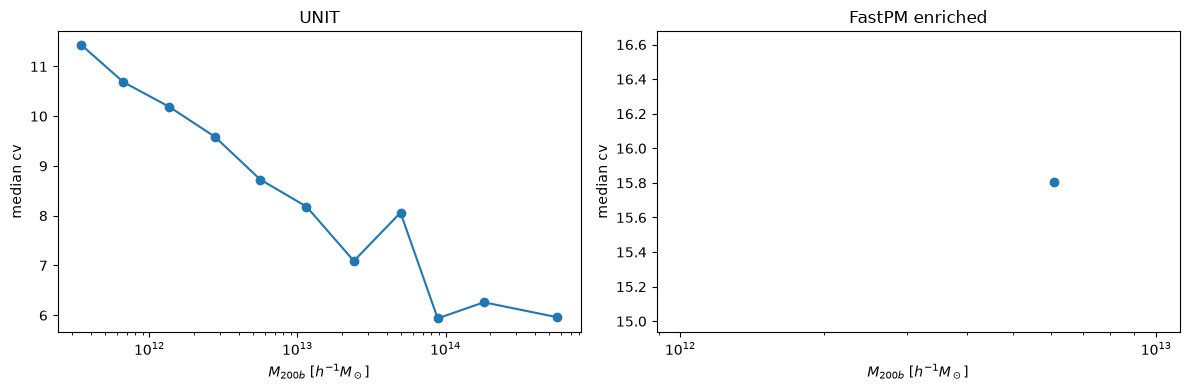

In [22]:
import matplotlib.pyplot as plt
from density_field_properties.haloscope.sim_to_fastpm.plotting import median_property_vs_mass

mass_range = (np.log10(halos_sim["M200b"].min()), np.log10(halos_sim["M200b"].max()))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, catalog, label in (
    (axes[0], halos_sim, "UNIT"),
    (axes[1], halos_fastpm_enriched, "FastPM enriched"),
):
    mass_centers, medians = median_property_vs_mass(
        catalog["M200b"].to_numpy(),
        catalog["cv"].to_numpy(),
        mass_range,
    )
    axis.plot(mass_centers, medians, marker="o")
    axis.set_xscale("log")
    axis.set_xlabel(r"$M_{200b}$ [$h^{-1} M_\odot$]")
    axis.set_ylabel("median cv")
    axis.set_title(label)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "median_cv_vs_mass_tidal.pdf")
plt.show()

## 8. Assembly bias with tidal inputs (HALOSCOPE Fig. 4 style)

HR reference: UNIT SIM, split by true `(cv, Spin, ca, ba)` into joint lower/upper 25% tails.
LR+HALOSCOPE: FastPM enriched catalog, split by **predicted** properties (`INPUT_FEATURES = t_over_u, tidal_anisotropy`).

Matter ``delta`` for Paranjape (same order for **UNIT** and **FastPM**):
1. Saved CIC under `output/unit_files/` or `output/fast_pm_bigfile/` (see `config.py`)
2. DM particle file / BigFile
3. Halo CIC weighted by `M200b`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from density_field_properties.haloscope.sim_to_fastpm.assembly_bias import (
    assembly_bias_curves_for_catalog,
    attach_paranjape_bias,
    load_fastpm_matter_overdensity,
    load_sim_matter_overdensity,
    property_matrix_from_frame,
)
from density_field_properties.haloscope.sim_to_fastpm.config import (
    ASSEMBLY_BIAS_DM_BATCH_SIZE,
    DM_MASS_PARTICLE_MSUN_H,
    OUTPUT_FEATURES,
    default_fastpm_dm_particles_path,
)
from density_field_properties.haloscope.sim_to_fastpm.plotting import plot_assembly_bias_env_panel

ASSEMBLY_BIAS_N_GRID = 128
ASSEMBLY_LOG_MASS_BINS = np.linspace(11.5, np.log10(halos_sim["M200b"].max()), 10)

delta_sim, sim_delta_mode = load_sim_matter_overdensity(
    REPO_ROOT,
    SIM_BOXSIZE_MPC_H,
    ASSEMBLY_BIAS_N_GRID,
    DM_MASS_PARTICLE_MSUN_H,
    dm_batch_size=ASSEMBLY_BIAS_DM_BATCH_SIZE,
)
delta_fastpm, fp_delta_mode = load_fastpm_matter_overdensity(
    REPO_ROOT,
    FASTPM_BOXSIZE_MPC_H,
    ASSEMBLY_BIAS_N_GRID,
    DM_MASS_PARTICLE_MSUN_H,
    default_fastpm_dm_particles_path(),
    dm_batch_size=ASSEMBLY_BIAS_DM_BATCH_SIZE,
)
if delta_sim is None:
    sim_delta_mode = "halo CIC"
else:
    print(f"UNIT matter delta source: {sim_delta_mode}")
if delta_fastpm is None:
    fp_delta_mode = "halo CIC"
else:
    print(f"FastPM matter delta source: {fp_delta_mode}")

halos_sim["b1"] = attach_paranjape_bias(
    halos_sim,
    SIM_BOXSIZE_MPC_H,
    n_grid=ASSEMBLY_BIAS_N_GRID,
    matter_delta_field=delta_sim,
)
fp_for_bias = halos_fastpm_enriched.dropna(subset=list(OUTPUT_FEATURES)).copy()
halos_fastpm_enriched.loc[fp_for_bias.index, "b1"] = attach_paranjape_bias(
    fp_for_bias,
    FASTPM_BOXSIZE_MPC_H,
    n_grid=ASSEMBLY_BIAS_N_GRID,
    mass_column=MASS_COL_FASTPM,
    matter_delta_field=delta_fastpm,
)
fp_for_bias = halos_fastpm_enriched.dropna(subset=["b1"] + list(OUTPUT_FEATURES)).copy()

hr_props = property_matrix_from_frame(halos_sim, OUTPUT_FEATURES)
lr_props = property_matrix_from_frame(fp_for_bias, OUTPUT_FEATURES)

hr_curves = assembly_bias_curves_for_catalog(
    halos_sim["M200b"].to_numpy(),
    halos_sim["b1"].to_numpy(),
    hr_props,
    ASSEMBLY_LOG_MASS_BINS,
)
lr_curves = assembly_bias_curves_for_catalog(
    fp_for_bias[MASS_COL_FASTPM].to_numpy(),
    fp_for_bias["b1"].to_numpy(),
    lr_props,
    ASSEMBLY_LOG_MASS_BINS,
)

fig = plot_assembly_bias_env_panel(
    *hr_curves,
    lr_curves[0],
    lr_curves[1],
    lr_curves[3],
    lr_curves[4],
    title=(
        "input: T/|U| + tidal anisotropy "
        f"(HR δ: {sim_delta_mode}, FastPM δ: {fp_delta_mode})"
    ),
    output_path=str(OUTPUT_DIR / "assembly_bias_tidal_input.pdf"),
)
plt.show()
print("saved:", OUTPUT_DIR / "assembly_bias_tidal_input.pdf")

## 9. One-shot pipeline helper (optional)

The cell below mirrors `scripts/run_sim_to_fastpm_haloscope_tidal.py` for a single call from the notebook.

**Slurm (same limits as `QUICK_RUN=True` here):**

```bash
sbatch slurm/sim_to_fastpm/main_sim_to_fastpm_haloscope_tidal_smoke.slurm
```

**Slurm (full catalogs + assembly-bias PDF):**

```bash
sbatch slurm/sim_to_fastpm/main_sim_to_fastpm_haloscope_tidal.slurm
```

**Local CLI equivalent to this notebook:**

```bash
PYTHONPATH=src python scripts/run_sim_to_fastpm_haloscope_tidal.py --quick-run --assembly-bias
```

In [23]:
RUN_PIPELINE_HELPER = False

if RUN_PIPELINE_HELPER:
    from density_field_properties.haloscope.sim_to_fastpm.pipeline_tidal import (
        run_sim_to_fastpm_haloscope_tidal_pipeline,
    )

    pipeline_output = run_sim_to_fastpm_haloscope_tidal_pipeline(
        sim_hlist_path=SIM_PATH,
        fastpm_list_path=FASTPM_PATH,
        repo_root=REPO_ROOT,
        max_sim_halos=MAX_SIM_HALOS,
        max_fastpm_halos=MAX_FASTPM_HALOS,
        max_descriptor_batch_files=MAX_DESCRIPTOR_BATCHES,
        output_dir=OUTPUT_DIR,
        min_bin_size=MIN_BIN_SIZE,
    )
    print(pipeline_output)